In [27]:
# imports
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.indicators.hv import HV
import random
from itertools import combinations
import geopandas as gpd

In [28]:
data = Path.cwd().parent.parent.joinpath("processed_data", "candidates_ranked.csv")
df = pd.read_csv(data)
df.head()

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score,rank
0,40075,Kiowa County,8181.0,42679.0,4700.0,157935.0,0.0,2.112674e+08,0.079146,10,...,138.0,110.400000,2.0,4.108833e+07,0.015393,2669.336760,3.064806,0,0.529671,1880.0
1,46079,Lake County,10993.0,74884.0,5714.0,170505.0,0.0,1.890356e+08,0.126898,48,...,69.0,69.000000,156.0,1.136746e+08,0.076309,1489.662955,7.379522,0,0.591694,1349.0
2,37033,Caswell County,22563.0,56999.0,10493.0,295896.0,0.0,6.618573e+07,0.059609,4,...,230.0,230.000000,16.0,1.409890e+07,0.012698,1110.336635,20.320864,0,0.637095,799.0
3,48377,Presidio County,5433.0,29012.0,3396.0,106309.0,0.0,0.000000e+00,0.000000,0,...,69.0,69.000000,16.0,3.486332e+08,0.034909,9986.831983,0.544016,0,0.585314,1404.0
4,39057,Greene County,174322.0,81243.0,71471.0,2239244.0,0.0,1.002618e+08,0.092999,8,...,345.0,112.909091,58.0,1.130754e+07,0.010488,1078.100699,161.693616,0,0.596162,1284.0


## Goal
Recommend optimal counties in the US to be a nuclear reactor site. These counties shouldn't be dominated in any criteria (e.g. scoring very high in 1 criterion but very low in another). 

## Method
- Use <a href = "https://codemonk.io/blog/a-gentle-introduction-to-multi-objective-optimization/">multi-objective optimization (MOO)</a> to find a subset of non-dominated counties. That subset is also called a ***pareto front***

- We'll use MOO on both **the full dataset** and **the top 10% counties with the highest suitability (MCDA) score** (see our `scoring.ipynb`). This is to measure how much our expert-driven weights narrow the candidate space compared to a weight-free approach (MOO).

- We'll get 2 pareto fronts: one is the optimal counties in the full dataset, another one is the optimal counties only within the top scoring candidates

- The counties appearing on both pareto fronts are the strongest recommendations, as they're validated by both domain knowledge and objective dominance 

- Package: `pymoo` (`NonDominatedSorting` algorithm)

**Step 1: Define objectives**

- `NonDominatedSorting` (and MOO in general) works best when we reduce the number of objectives as much as possible. So we chose 6 objectives (variables) that are non-repeating and non-redundant.
- By default, `NonDominatedSorting` will minimize the objectives, so for variables where higher values mean better, we negate them to make sure we're doing a minimization problem

In [29]:
# defining objectives to be optimized -- works best when we reduce the numbers of objectives as much as possible
# goal: minimize all objectives (by default by NonDominatedSorting) ==> negate variables where higher values mean better 

objectives = [
    "pga_max",
    "pct_sfha",
    "population_density",
    "dist_to_lakes_km",
    "distance_to_lines_km",
    "total_energy_consumption_mwh"
]

higher_better = [
    "total_energy_consumption_mwh"
]

idx_higher_better = [objectives.index(f) for f in higher_better]
idx_higher_better

[5]

In [30]:
# drop null values in the objectives, NonDominatedSorting does not work with null

df_clean = df.dropna(subset = objectives).reset_index(drop = True)
df_clean.shape

(2141, 36)

**Step 2: Run MOO twice on our top-scoring counties and our full dataset**

- Take the objectives from our dataset and turn them into a matrix. Negate the `higher_better` variables
- Return the non-dominated counties (pareto front) from each subset of data

In [31]:
# multi-objective optimization on full dataset (null values dropped)
model = NonDominatedSorting()

matrix_full = df_clean[objectives].values.astype(float)
matrix_full[:, idx_higher_better] = -matrix_full[:, idx_higher_better]

pareto_full_matrix = model.do(matrix_full, only_non_dominated_front = True)
pareto_full_df = df_clean.index.values[pareto_full_matrix]
pareto_full = matrix_full[pareto_full_matrix]


# multi-objective optimization on top candidtes by our scoring framework 
n_top = int(len(df_clean) / 10)

idx_top_10_pct = df_clean.nlargest(n_top, "mcda_score").index.values
matrix_top = df_clean.loc[idx_top_10_pct, objectives].values.astype(float)
matrix_top[:, idx_higher_better] = -matrix_top[:, idx_higher_better]

pareto_top_matrix = model.do(matrix_top, only_non_dominated_front = True)
pareto_top_df = idx_top_10_pct[pareto_top_matrix]
pareto_top = matrix_top[pareto_top_matrix]

# results
print(f"Full dataset Pareto front: {len(pareto_full_df)} counties")
print(f"MCDA top-10% Pareto front (with {n_top} counties): {len(pareto_top_df)} counties")

Full dataset Pareto front: 744 counties
MCDA top-10% Pareto front (with 214 counties): 176 counties


In [32]:
density_full = len(pareto_full_df) / len(df_clean)
density_top = len(pareto_top_df) / n_top

print(f"Full dataset Pareto density: {density_full:.2%}")
print(f"MCDA top 10% Pareto density: {density_top:.2%}")

Full dataset Pareto density: 34.75%
MCDA top 10% Pareto density: 82.24%


**Step 3: Key metrics**
- We'll look at some key metrics of a multi-objective optimization model to evaluate how well our top 10% scoring candidates can capture the non-dominated counties in the full dataset (we'll call it the global pareto front)

- We first look at the **number of overlapping counties between two pareto fronts**, and **the number of counties in the global pareto that got excluded by our scoring framework**

- However, given the size difference between the full data and the top 10% candidates, these may not be the most objective metrics. We also look at the hypervolume (a standard MOO metric that measures how diverse the trade-off options in a pareto front are)

- Higher hypervolume = the optimal counties excel in different ways (across different criteria). We'll compare the two hypervolume to see how much of that diversity our top 10% candidates can preserve

In [33]:
# metrics 

# global recall and overlap counts
overlap = set(pareto_full_df) & set(pareto_top_df)
missed_by_mcda = set(pareto_full_df) - set(pareto_top_df)
recall = len(overlap) / len(pareto_full_df)
mcda_in_global = len(overlap) / len(pareto_top_df)

print(f"Overlap (both fronts): {len(overlap)}")
print(f"Global front missed by MCDA: {len(missed_by_mcda)}")
print(f"Recall: {recall:.2%}")
print(f"Pareto precision = fraction of MCDA Pareto solutions that are globally Pareto-optimal: {mcda_in_global:.2%}")

# hypervolume
# reference point = worst points, because we want to minimize all objectives => worst case is max
reference_point = np.max(np.vstack([pareto_full, pareto_top]), axis = 0) + 0.01 
hypervolume = HV(ref_point = reference_point)
hv_full = hypervolume(pareto_full)
hv_top = hypervolume(pareto_top)

print(f"Hypervolume on full dataset: {hv_full}")
print(f"Hypervolume on MCDA top candidates: {hv_top}")
if hv_full > 0:
    print(f"MCDA captures {hv_top/hv_full:.1%} of global hypervolume")

Overlap (both fronts): 175
Global front missed by MCDA: 569
Recall: 23.52%
Pareto precision = fraction of MCDA Pareto solutions that are globally Pareto-optimal: 99.43%
Hypervolume on full dataset: 294967878205477.3
Hypervolume on MCDA top candidates: 270323263021023.0
MCDA captures 91.6% of global hypervolume


**Some metrics observations**:

- Raw numbers: **175 counties** appear on both pareto fronts (strong sites). **569 counties** appear in the global front, but not in the top-candidate ones. These counties are non-dominated but were excluded by our weights. Our MCDA top 10% captures only 23.5% of the globally Pareto-optimal counties by count

- However, given that the top candidates subset is only 10% of the full dataset, the low recall is expected, so we use another evaluation metric: 

    - The **hypervolume ratio** (indicator of how much of the trade-off space a Pareto front covers; the ratio indicates how much of the global pareto front's trade-off coverage our MCDA top 10% preserves.): 91.6% => our MCDA front covers nearly as much of the range of possible trade-offs as the full dataset front

**Step 4: Locating the best counties**

We have 3 tiers (or groups because I think tiers don't necessarily reflect which one is better, esp. in tier 2 and 3) of recommendations:
- **Tier 1**: counties appearing in both pareto fronts (with both high suitability scores and not being dominated by other counties in any criteria)

- **Tier 2**: counties in top 10% front, but not in global front (they pass our expert-driven framework, but aren't non-dominated)

- **Tier 3**: counties in global front, but not in top 10% front (they are non-dominated, but was overlooked by our expert-driven scores, which is pretty interesting mathematically -- also a reason why we combine our **scoring framework** with **multi-objective optimization**)

In [34]:
# define tiers for counties
# appear in both pareto fronts => tier 1 (strong sites)
# in mcda_top fronts, but not in global => tier 2
# in global fronts, but not in mcda_top => tier 3
# not in both => unplaced

df_clean["in_pareto_full"] = df_clean.index.isin(pareto_full_df)
df_clean["in_pareto_top"] = df_clean.index.isin(pareto_top_df)

def return_tier(row):
    if (row["in_pareto_full"] == True) and (row["in_pareto_top"] == True):
        return "tier 1"
    elif (row["in_pareto_full"] == False) and (row["in_pareto_top"] == True):
        return "tier 2"
    elif (row["in_pareto_full"] == True) and (row["in_pareto_top"] == False):
        return "tier 3"
    else:
        return "none"
    
df_clean["tier"] = df_clean.apply(return_tier, axis = 1)
df_clean["tier"].value_counts()

tier
none      1396
tier 3     569
tier 1     175
tier 2       1
Name: count, dtype: int64

Observe the best 20 counties recommended by **our scoring framework alone** and by **multi-objective optimization** (and see how well they match)

In [38]:
# observe tier 1 counties (strong sites), using mcda_score as tie-breakers
# top 20 strong sites by multi-objective optimization

df_tier1 = df_clean[df_clean["tier"] == "tier 1"].sort_values("mcda_score", ascending = False)
moo_best = df_tier1[["geo_id", "county_name", "mcda_score"]].nlargest(20, "mcda_score")
mcda_best = df.nlargest(20, "mcda_score")[["geo_id", "county_name", "mcda_score"]]

print(f"Best 20 counties by MOO (tie breaker by MCDA score):\n {moo_best}\n")
print(f"Best 20 counties by MCDA scores only:\n {mcda_best}\n")

moo_best_id = set(moo_best["geo_id"].values)
mcda_best_id = set(mcda_best["geo_id"].values)
print(f"Number of overlap counties in both top 20: {len(moo_best_id & mcda_best_id)}")

Best 20 counties by MOO (tie breaker by MCDA score):
       geo_id          county_name  mcda_score
972    55079     Milwaukee County    0.810858
2008   26131     Ontonagon County    0.794073
182    55003       Ashland County    0.789878
2031   26003         Alger County    0.784472
1122   26061      Houghton County    0.783513
1709   26009        Antrim County    0.777135
242    26103     Marquette County    0.771867
1038   55061      Kewaunee County    0.770808
661    26047         Emmet County    0.768598
701    26151       Sanilac County    0.768182
888    55089       Ozaukee County    0.762439
1376   26141  Presque Isle County    0.761511
406    26101      Manistee County    0.758692
746    26063         Huron County    0.754069
2032   48215       Hidalgo County    0.752772
534    26105         Mason County    0.751384
747    26069         Iosco County    0.748926
1046   26127        Oceana County    0.743426
1978   26041         Delta County    0.743324
303    38025          Dunn

**Results**: 18 out of 20 counties recommended by our MCDA scores and MOO independently agree, which confirms strong consistency between our expert-driven and data-driven approaches. The recommendations are robust and reliable.

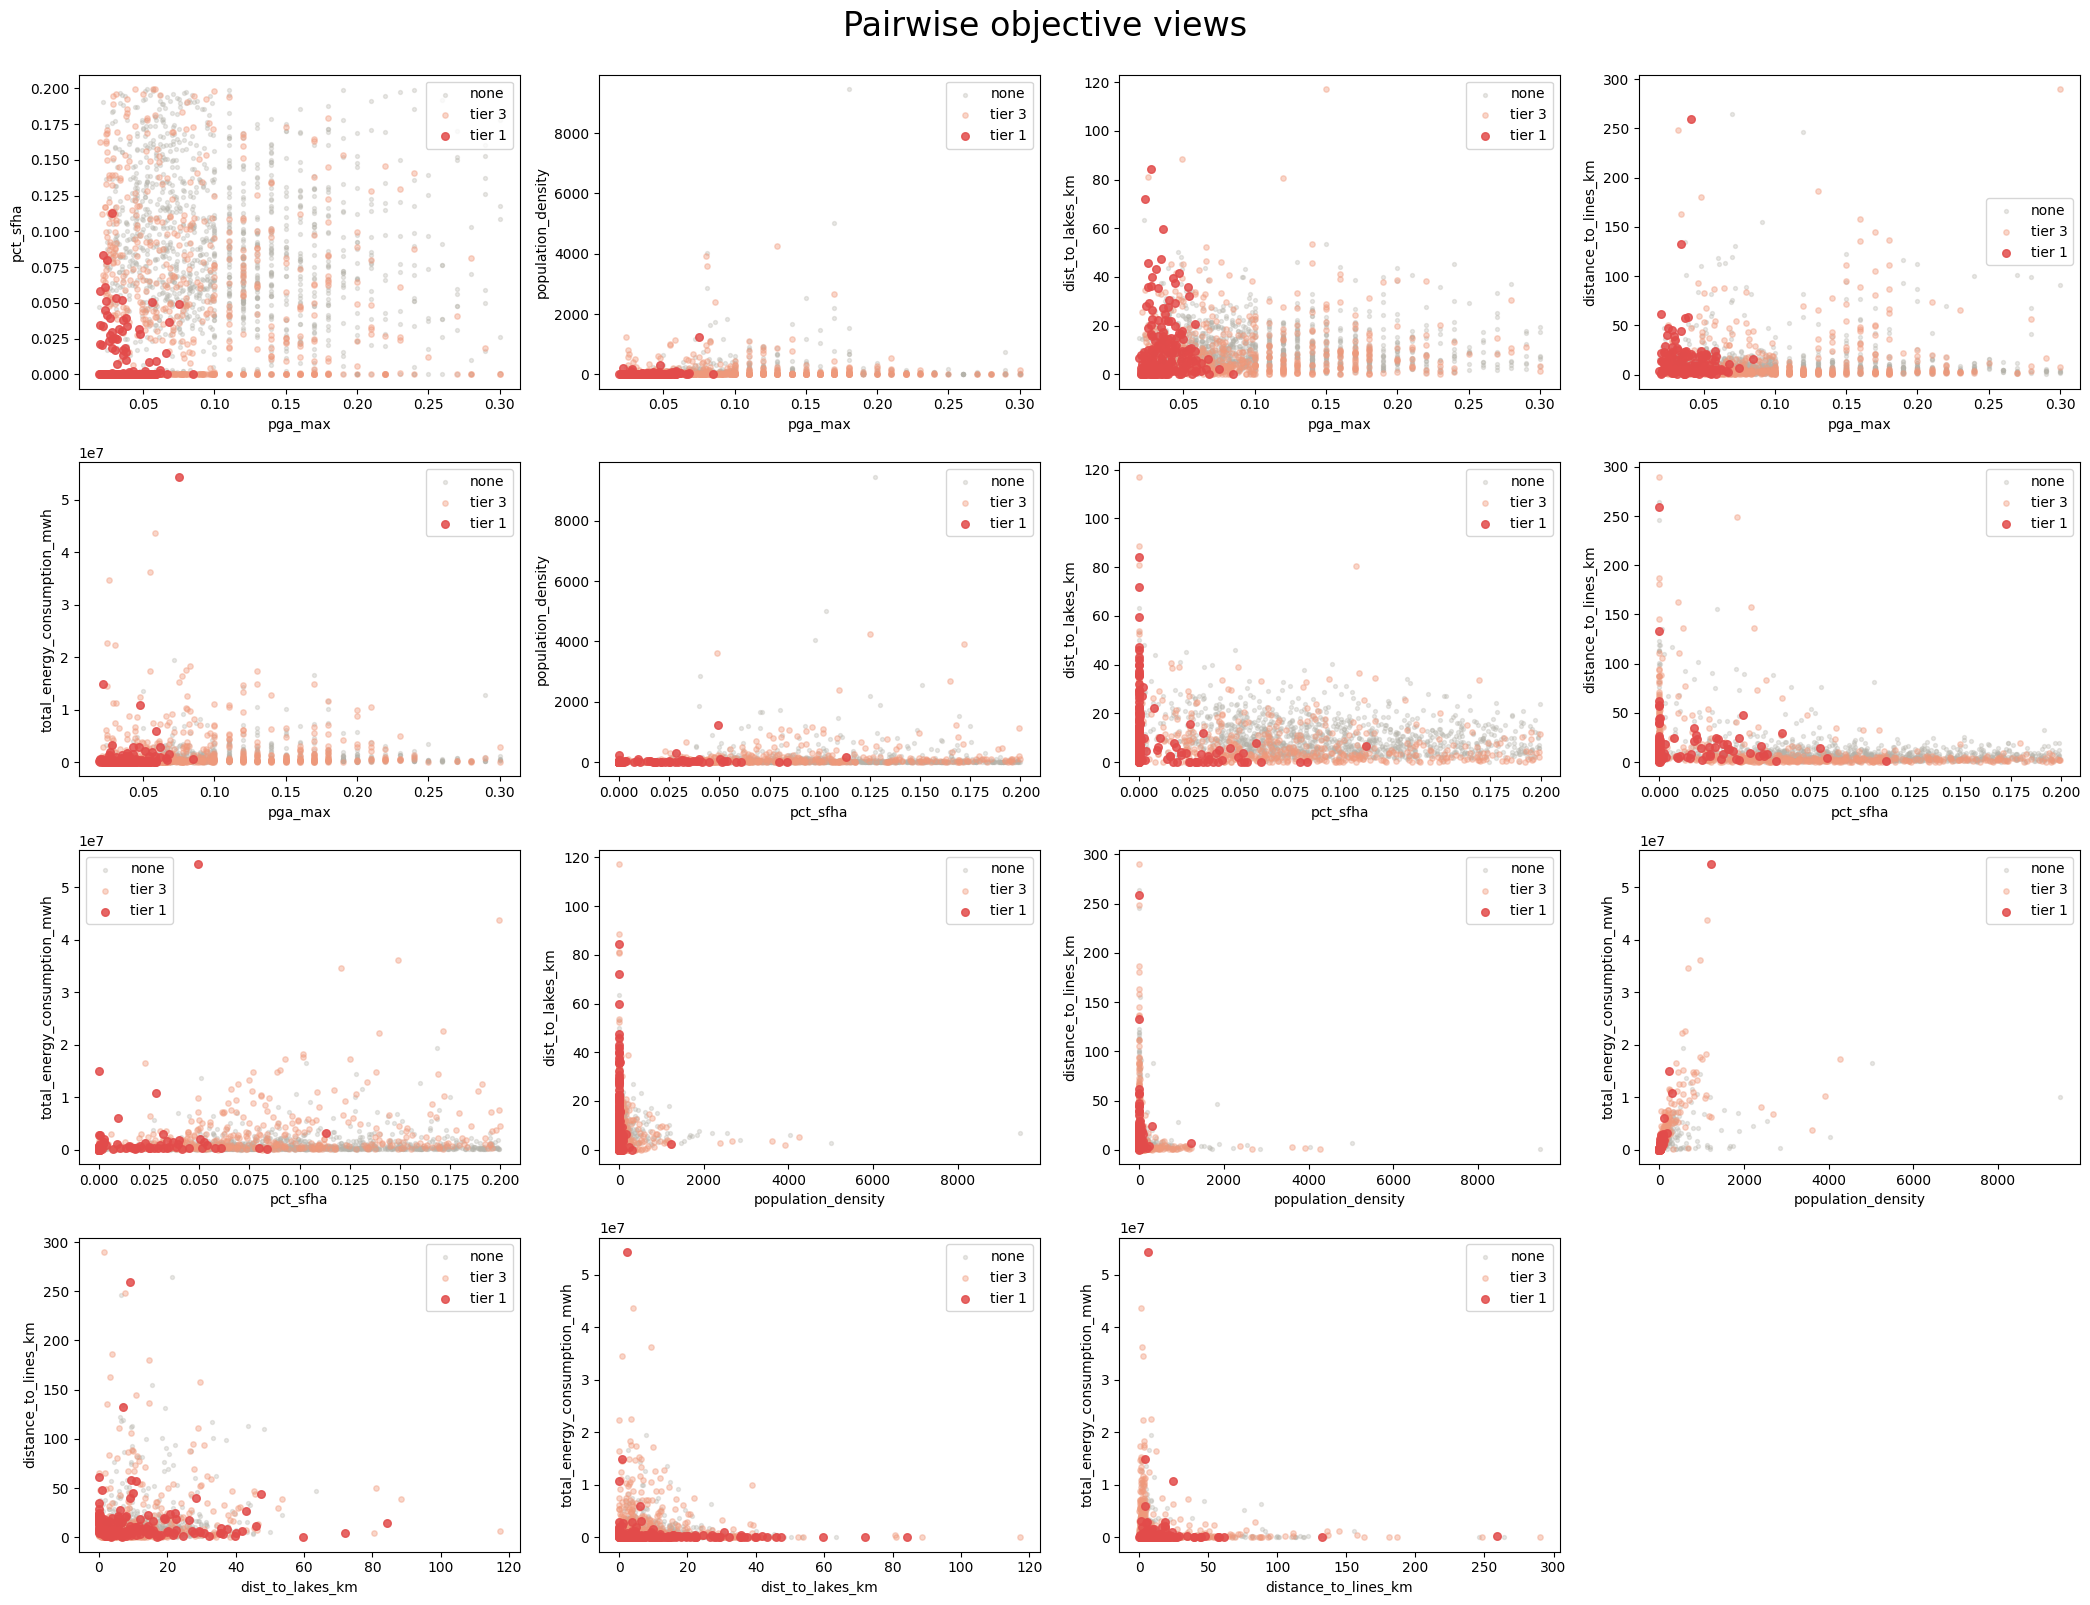

In [ ]:
# some result visualizations
# pairwise objective views to see where strong sites locate

fig, axes = plt.subplots(4, 4, figsize = (21, 16))

objective_pairs = list(combinations(objectives, 2))

color = {'none': '#B4B2A9', 'tier 3': '#F0997B', 'tier 1': '#E24B4A'}
sizes = {'none': 8, 'tier 3': 15, 'tier 1': 30}
alphas = {'none': 0.3, 'tier 3': 0.4, 'tier 1': 0.85}

for ax, (objective_x, objective_y) in zip(axes.flat, objective_pairs):
    for tier in ["none", "tier 3", "tier 1"]:
        subset = df_clean[df_clean["tier"] == tier]
        ax.scatter(
            subset[objective_x],
            subset[objective_y],
            c = color[tier],
            s = sizes[tier],
            alpha = alphas[tier],
            label = tier
        )
        ax.set_xlabel(objective_x)
        ax.set_ylabel(objective_y)
        ax.legend()

fig.delaxes(axes[3, 3])
plt.suptitle("Pairwise objective views", fontsize = 24, y = 1.0)
plt.tight_layout()
plt.savefig("../../results/pairwise_scatterplot_moo.png", bbox_inches = "tight")

In [ ]:
county = Path.cwd().parent.parent.joinpath("raw_data", "county_boundaries_2025", "tl_2025_us_county.shp")
df_county = gpd.read_file(county)[["GEOID", "STATEFP", "NAMELSAD", "geometry"]]
df_county.columns = ["geo_id", "state_fips", "county_name", "geometry"]

df_county['geo_id'] = df_county['geo_id'].astype(str).str.zfill(5)
df_clean['geo_id'] = df_clean['geo_id'].astype(str).str.zfill(5)

contiguous_fips = [str(i).zfill(2) for i in range(1, 57) if i not in [2, 15, 52, 53, 54, 55, 56]]
df_county = df_county[df_county['state_fips'].isin(contiguous_fips)]

In [ ]:
merged = df_county.merge(df_clean[['geo_id', 'tier', 'mcda_score']], on = 'geo_id', how = 'left')
merged['tier'] = merged['tier'].fillna('none')
merged

,geo_id,state_fips,county_name,geometry,tier,mcda_score
0,40075,40,Kiowa County,"POLYGON ((-98.95506 35.11643, -98.94903 35.116...",none,0.529671
1,46079,46,Lake County,"POLYGON ((-96.88886 43.9353, -96.88886 43.9351...",none,0.591694
2,37033,37,Caswell County,"POLYGON ((-79.14343 36.4422, -79.14345 36.4418...",none,0.637095
3,48377,48,Presidio County,"POLYGON ((-104.98078 30.62552, -104.98073 30.6...",tier 3,0.585314
4,39057,39,Greene County,"POLYGON ((-84.10668 39.68891, -84.10662 39.689...",none,0.596162
...,...,...,...,...,...,...
2915,21079,21,Garrard County,"POLYGON ((-84.74545 37.71562, -84.74501 37.716...",none,0.617276
2916,19177,19,Van Buren County,"POLYGON ((-92.17907 40.89972, -92.17704 40.899...",none,0.591920
2917,31073,31,Gosper County,"POLYGON ((-99.98139 40.62501, -99.9814 40.6269...",none,0.650589
2918,28095,28,Monroe County,"POLYGON ((-88.22909 33.89194, -88.2291 33.8918...",none,NaN


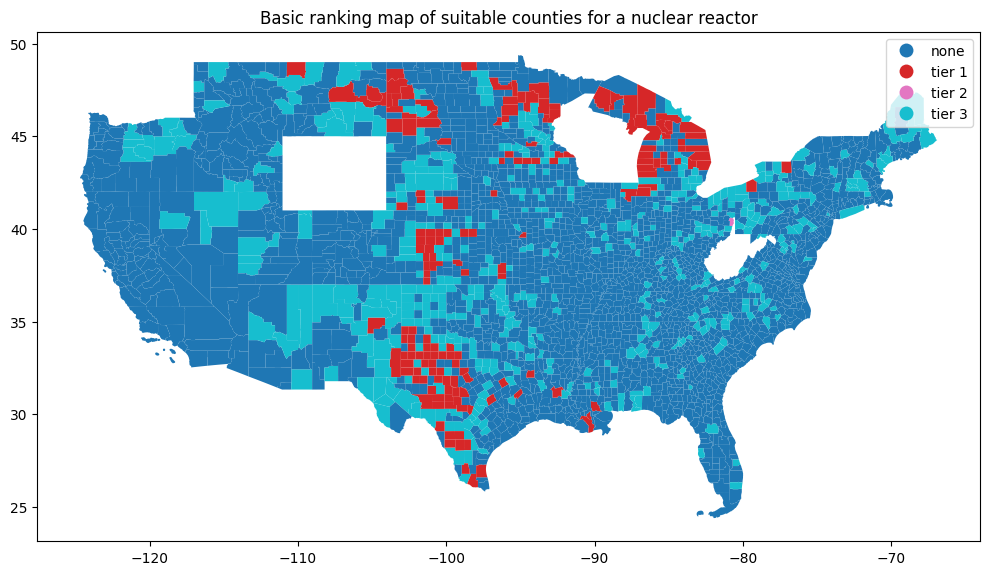

In [ ]:
merged.plot(column = "tier", figsize = (10, 6), legend = "tier")
plt.title("Basic ranking map of suitable counties for a nuclear reactor")
plt.tight_layout()